In [3]:
 # --- 1. Environment Initialization ---
import numpy as np
import pandas as pd
print(f"Pandas version: {pd.__version__}")
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set seaborn plotting style for clean, readable white-grid backgrounds
sns.set_theme(style="whitegrid")
# Default all generated figures to a wide 12x6 aspect ratio
plt.rcParams['figure.figsize'] = (12, 6)

Pandas version: 2.3.3


In [4]:
# --- 2. Data Loading & Processing ---
# Load the newest JSON file
JSON_FILE = "zx50_sweep_1774835514.json"
with open(JSON_FILE, 'r') as f:
    raw_data = json.load(f)

rows = []
for run in raw_data['test_runs']:
    freq = run['source_waveform']['frequency_hz']
    for m in run['measurements']:
        # Extract means, converting None/null to NaN for Pandas
        rows.append({
            'Frequency_Hz': freq,
            'TX_Pin': m['tx_pin'],
            'RX_Pin': m['rx_pin'],
            'TX_Signal': m['tx_signal_name'],
            'RX_Signal': m['rx_signal_name'],
            'CH1_Vpp': m['ch1_vpp'].get('mean'),
            'CH4_Vpp': m['ch4_vpp'].get('mean'),
            'Phase_Shift_Deg': m['phase'].get('mean'),
            'Rise_Time_ns': (m['rise_time']['mean'] * 1e9) if m['rise_time'].get('mean') else None,
            'Fall_Time_ns': (m['fall_time']['mean'] * 1e9) if m['fall_time'].get('mean') else None,
            'VHigh': m['ch4_vhigh'].get('mean'),
            'VLow': m['ch4_vlow'].get('mean'),
        })

df = pd.DataFrame(rows)

# Existing Analysis Logic
df['Gain_dB'] = 20 * np.log10(df['CH4_Vpp'] / df['CH1_Vpp'])
df['Freq_Label'] = (df['Frequency_Hz'] / 1e6).astype(str) + ' MHz'

df_main = df[df['TX_Pin'] == df['RX_Pin']].copy()
df_cross = df[df['TX_Pin'] != df['RX_Pin']].copy()

display(df.head())

,Frequency_Hz,TX_Pin,RX_Pin,TX_Signal,RX_Signal,CH1_Vpp,CH4_Vpp,Phase_Shift_Deg,Rise_Time_ns,Fall_Time_ns,VHigh,VLow,Gain_dB,Freq_Label
0,100000,42,42,CLK,CLK,4.4861,3.595400,1.8748,51.5494,80.1234,4.7969,1.4431,-1.922435,0.1 MHz
1,100000,42,40,CLK,~HALT~,4.9065,0.295477,-172.5090,1832.2000,1980.2000,4.1661,3.8707,-24.404960,0.1 MHz
2,100000,42,44,CLK,MCLK,4.9536,0.304634,-173.3364,4548.7000,5684.4000,3.7506,3.4510,-24.222863,0.1 MHz
3,1000000,42,42,CLK,CLK,4.4560,3.651200,10.7474,29.4153,61.1851,4.8000,1.4400,-1.730191,1.0 MHz
4,1000000,42,40,CLK,~HALT~,5.8322,0.301184,-98.5847,165.2314,155.0721,4.1646,3.8646,-25.740010,1.0 MHz


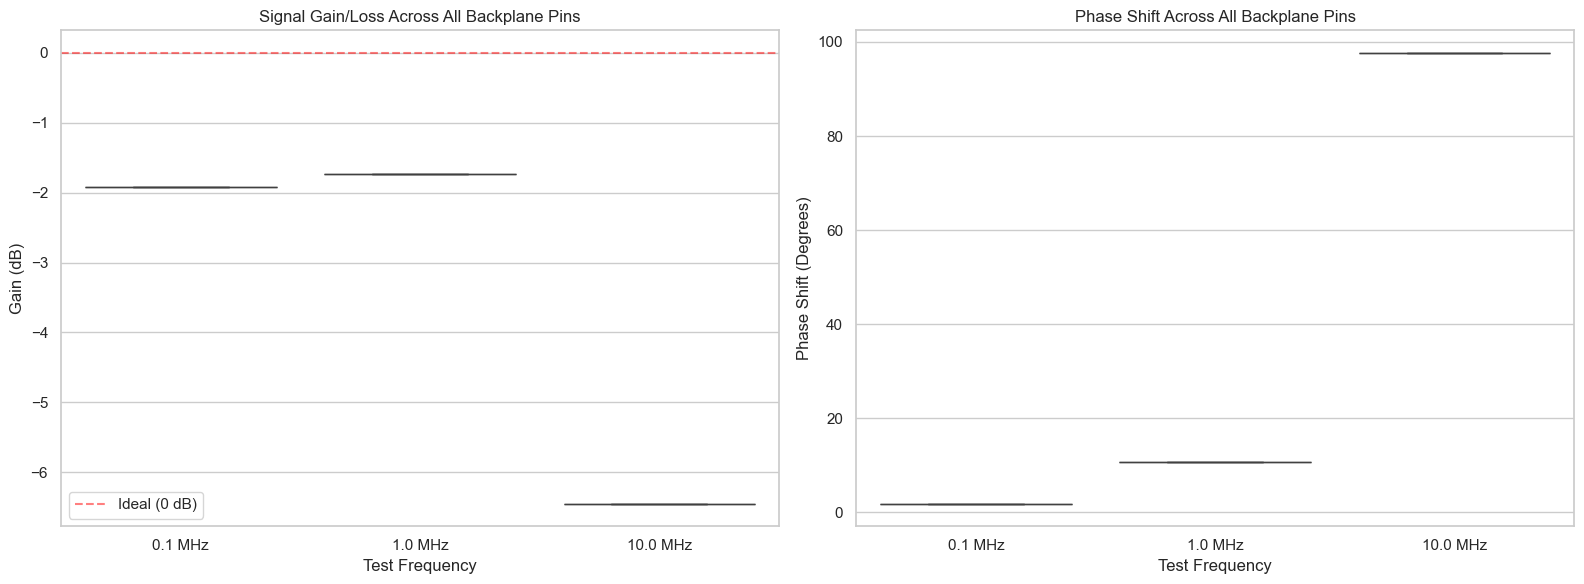

In [5]:
# --- 3. Global Signal Integrity Summary ---
# Visualizes the total spread of signal degradation across the entire backplane.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Gain/Loss Spread
sns.boxplot(data=df_main, x='Freq_Label', y='Gain_dB', hue='Freq_Label', palette="Blues", legend=False, ax=axes[0])
axes[0].set_title("Signal Gain/Loss Across All Backplane Pins")
axes[0].set_ylabel("Gain (dB)")
axes[0].set_xlabel("Test Frequency")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label="Ideal (0 dB)")
axes[0].legend()

# Subplot B: Phase Shift Spread
# (If Phase_Shift_Deg was recorded in the CSV)
if 'Phase_Shift_Deg' in df_main.columns:
    sns.boxplot(data=df_main, x='Freq_Label', y='Phase_Shift_Deg', hue='Freq_Label', palette="Oranges", legend=False, ax=axes[1])
    axes[1].set_title("Phase Shift Across All Backplane Pins")
    axes[1].set_ylabel("Phase Shift (Degrees)")
    axes[1].set_xlabel("Test Frequency")

plt.tight_layout()
plt.show()

In [6]:
# --- 4. Identify Worst Offenders ---
# Filters down to the highest frequency (10 MHz) and sorts to find the traces with the most dB loss.
df_main_10mhz = df_main[df_main['Frequency_Hz'] == 10_000_000].copy()

# Sort ascending by Gain_dB (The most negative number represents the highest signal loss)
worst_attenuation = df_main_10mhz.sort_values(by='Gain_dB', ascending=True).head(10)

print("--- Worst Performing Pins at 10 MHz (Signal Loss) ---")
display(worst_attenuation[['TX_Pin', 'TX_Signal', 'Gain_dB']])

--- Worst Performing Pins at 10 MHz (Signal Loss) ---


,TX_Pin,TX_Signal,Gain_dB
6,42,CLK,-6.451362


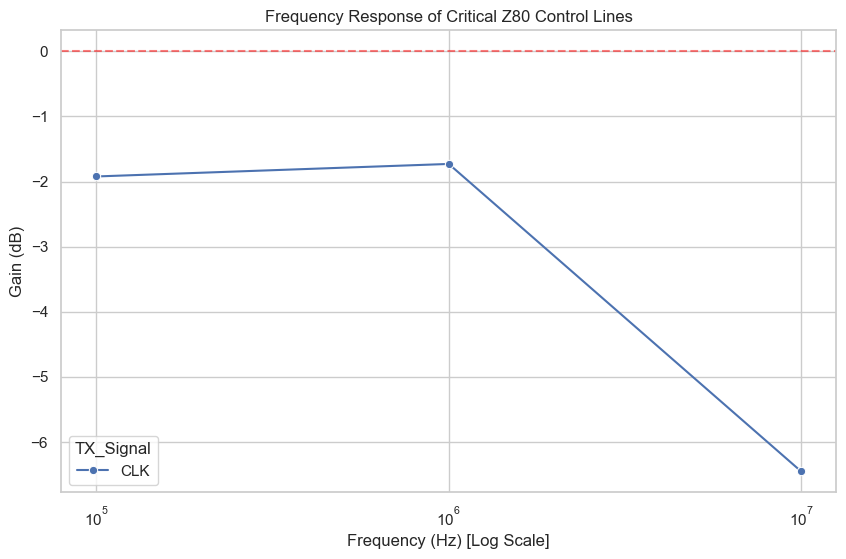

In [7]:
# --- 5. Frequency Response of Critical Lines ---
# Plots how specific, high-importance Z80 traces roll off as frequency increases.
critical_signals = ['MCLK', 'CLK', '~WAIT~', '~MREQ~']
df_crit = df_main[df_main['TX_Signal'].isin(critical_signals)]

if not df_crit.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_crit, x='Frequency_Hz', y='Gain_dB', hue='TX_Signal', marker='o')

    plt.xscale('log') # Log scale visually linearizes the 100k -> 1M -> 10M steps
    plt.title("Frequency Response of Critical Z80 Control Lines")
    plt.ylabel("Gain (dB)")
    plt.xlabel("Frequency (Hz) [Log Scale]")
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.show()
else:
    print("Critical signals not found in dataset. Check your signal names.")

In [2]:
# --- 6. Crosstalk & Noise Coupling Analysis ---
# Visualizes how much voltage is bleeding onto adjacent pins from a target source pin[cite: 142].
TARGET_TX_PIN = 42

# Filter the crosstalk-only dataframe for our target source
crosstalk_data = df_cross[df_cross['TX_Pin'] == TARGET_TX_PIN]

if not crosstalk_data.empty:
    plt.figure(figsize=(10, 6))

    # Barplot groups adjacent RX pins by Frequency to show how high frequencies bleed worse[cite: 156, 157, 158, 159].
    sns.barplot(data=crosstalk_data, x='RX_Pin', y='CH4_Vpp', hue='Freq_Label', palette='Reds')

    plt.title(f"Crosstalk (Noise Coupling) from TX Pin {TARGET_TX_PIN}")
    plt.ylabel("Induced Noise (Vpp)")
    plt.xlabel("Adjacent RX Pin")
    plt.legend(title="Test Frequency")

    # Typical TTL Logic threshold is ~0.8V. If noise exceeds this, the Z80 might read a false logic state[cite: 137, 138].
    plt.axhline(0.8, color='red', linestyle=':', label="TTL Logic Low Threshold (0.8V)")

    plt.show()
else:
    print(f"No crosstalk data found for TX Pin {TARGET_TX_PIN}.")

NameError: name 'df_cross' is not defined